<h2><b>Distribution of Random Walkers' Positions</b></h2>

In [1]:
## PACKAGES
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import leastsq
from IPython.display import display,HTML
from complements import complements 
import scipy.special as sp
from cycler import cycler

## INITIAL SETTINGS
plt.rcParams['font.family'] = 'monospace';
pd.set_option('display.max_columns', 101);

## PLOTTING SETTINGS
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

<html>
<head><link rel="stylesheet" href="complements/style.css"></head>
<body>
    <h3 style="margin-bottom: 15px; font-weight: bold;" id="contents">Contents</h4>
    <hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0;">
    
<div style="line-height:0px;padding-top:20px">
<a class="content-bullet" style="padding-left: 45px;" href="#about">About</a>

<a class="content-bullet" style="padding-left: 80px; font-size: 16px;" href="#moments">Moments</a>
</div>
<ol>
    <li class="content-bullet">
        <a href="#individual">Individual Random Walks</a>
    </li>
    <li class="content-bullet">
        <a href="#simple">Simple Random Walk</a>
        <ol>
            <li class="content-bullet sub">
                <a href="#simple:pos">Final Positions</a>
            </li>
            <li style="font-size: 16px;">
                <a href="#simple:vis">Visits</a>
            </li>
        </ol>
    </li>
    <li class="content-bullet">
        <a href="#resetting">Random Walk with Resetting</a>
        <ol>
            <li class="content-bullet sub">
                <a href="#resetting:pos">Final Positions</a>
            </li>
            <li style="font-size: 16px;">
                <a href="#resetting:vis">Visits</a>
            </li>
        </ol>
    </li>
    <li class="content-bullet">
        <a href="#memory">Random Walk with Memory</a>
        <ol>
            <li class="content-bullet sub">
                <a href="#memory:pos">Final Positions</a>
            </li>
            <li style="font-size: 16px;">
                <a href="#memory:vis">Visits</a>
            </li>
        </ol>
    </li>
</ol>
</body>
</html>

<head><link rel="stylesheet" href="complements/style.css"></head>
<h3 style="font-weight: bold; margin-bottom: 0;" id="about">About</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

The <b>Random Walk</b> is a widespread concept, pilar in many topics related to stochastic processes. It consists basically of a succession of random steps, and based on it, there are multiple ways in which we can create diversified dynamics.

This project was thought to serve as the fundaments to understand Random Walk theory and codding, to ease the later development of models based on random walkers. This Notebook assembles the results provided by the Fortran codes simulations, as well as giving some analytical background.

<a class="return-to-contents" href="#contents">◄ Return to Contents</a>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="moments">Moments</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

The results of this project are based mainly on Probability Density Functions (PDFs), and on the analysis of the statistical moments, unique properties of each distribution. There are a few concepts we need to discuss to get a better understanding of the following sections. We can define the <i>raw moments</i> of any variable $\small z$ as

\begin{equation*}
    {\rm E}[z] \equiv \mu_1 = \int_{-\infty}^{\infty} z \, P(z) \, {\rm d}z, \qquad {\rm E}[z^2] \equiv \mu_2 = \int_{-\infty}^{\infty} z^2 \, P(z) \, {\rm d}z, \qquad ... \qquad {\rm E}[z^N] \equiv \mu_N = \int_{-\infty}^{\infty} z^N \, P(z) \, {\rm d}z
\end{equation*}

Properties such as the variance, skewness and kurtosis are statistical moments calculated from the raw moments.

\begin{equation*}
    \mathbf{{\rm E}[(\mu - z)^2]} = {\rm E}[\mu^2] +{\rm E}[-2\mu z] + {\rm E}[z^2] = {\rm E}[z^2] - \mu^2 \equiv \mu_2 - \mu_1 ^2 = \mathbf{\Mu_2}
\end{equation*}

And the same goes for the following moments. In combination with these two, as long as we have an analytical PDF, we can try to calculate the statistical moments as well.

Inside the simulation, we have to consider discrete quantities, and the numerical calculation of raw moments obeys the following formula:

\begin{equation*}
    \mu_n \equiv \langle z^n \rangle = \frac{1}{m} \sum_{i=0}^{m} z_{i}^{n}
\end{equation*}

It is obvious to notice that this is just an average over the number of realizations $\small m$. In our simulations, $\small z$ corresponds to the final positions.

We should discuss a little more about the meaning of the statistical moments. These are quantities that showcase certain aspects of a Probability Distribution, we can even think of them as customized identifiers. The first one, the mean value, $\small \Mu_1$, represents a point that indicates the central tendency of the data, for symmetrical distributions, this lies on their axis of symmetry. In the context of Random Walks, this is usually $\small 0$. The next one is the variance, $\small \Mu_2$, indicating how far the data is scattered around the mean. In this topic, it can actually give us information about the final positions that walkers can reach, and what kind of dynamics their paths will follow. The third moment is pretty straightforward, it is called skewness, $\small \Mu_3$, and its value measures the symmetry of a distribution, if $\small 0$, the distribution is symmetric, if negative, it is skewed to the left, and if positive, it is skewed to the right. Finally, the fourth moment, the kurtosis, $\small \Mu_4$, refers to the form of the distribution, specifically the form of its tails. The higher the kurtosis, the wider the tails, and for lower values the majority of the data is concentrated around the mean, with small tails. For reference, the kurtosis of the normal distribution is $\small 3$.

<img style="padding-top: 20px; padding-bottom:15px; width: 35%; display: block; margin: auto;" src="complements/diagrams/moments_diagram.png">
<div class='caption'>Illustrative diagram about the effects of statistical moments on a distribution.</div>

There is a technical aspect that we have to consider to measure a distribution of random walker's positions, this is the possible final positions. To have a better idea, let's think about a random walk with 3 steps starting from 0: the first step, the walker can only be at $\small -1$ or $\small +1$, zero is not part of these options. In the second step, the walker can be at $\small -2,0,+2$, and we are starting to notice a pattern. In the final step, the trend is more visible, since the possible final positions of the walker are $\small -3, -1, 0, +1, +3$. Therefore, we see that the final position of the walker, in a discrete lattice, is dependent on the number of steps being odd or even, and a distribution measure under these circumstances would have gaps, depending on the number of steps. To counter this effect, at the final time, where we intend to measure the final positions, we only update half of the walkers, so that half of the final positions are odd and half are even numbers.

<a class="return-to-contents" href="#contents">◄ Return to Contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>
<h3 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="individual">1. Individual Random Walks</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

Before diving into the theory behind random walks, I want to briefly discuss the most general details about these processes. Starting from the <i>simple</i> case of the <b>random walk</b>, we can define it just as a succession of random steps, and visualize it by the sum of all the steps, let us name it $\small X$:

\begin{equation*}
    X = X_0 + X_1 + X_2 + ... + X_n
\end{equation*}

And, of course, the final value for $\small X$ depends on the number of steps $\small n$.

To make it easier to understand and study, these random steps can only be either $\small +1$ or $\small -1$, both of them can be chosen with a probability of $\small 1/2$. This can be thought of as a walker that can go up or down.

<a class="return-to-contents" href="#contents">◄ Return to Contents</a>

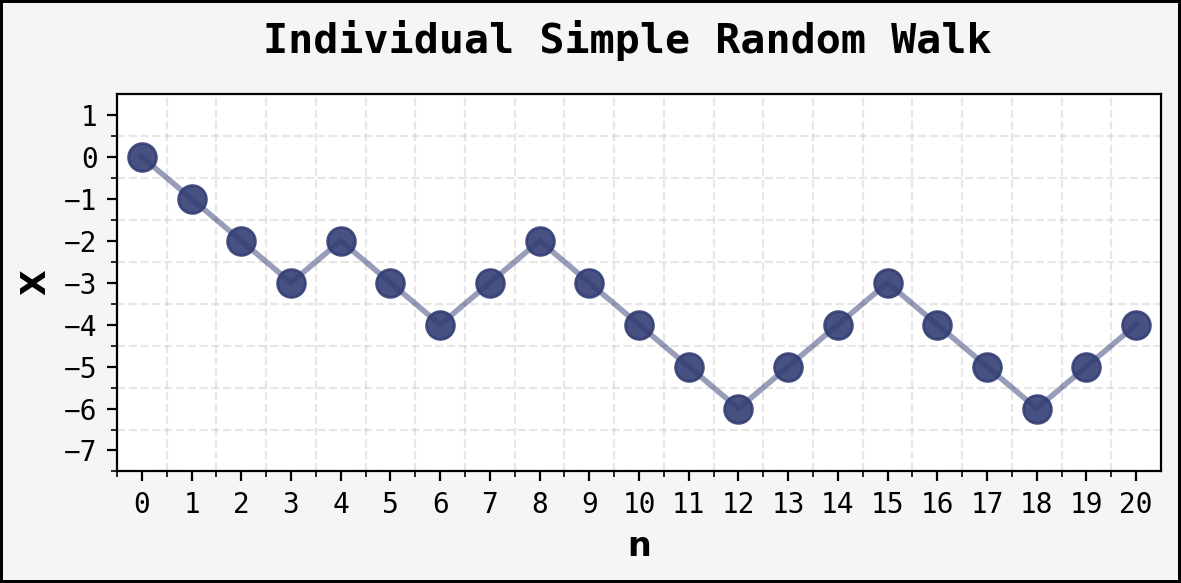

In [2]:
complements.individual_simple();

If instead of two choices ($\small +1,-1$), we could make the walker return to the start, $\small X_0$, with a probability $\small \gamma = 1/10$, that is, made it reset about every $\small 10$ steps, then we would have what we called the random walk with <b>resetting</b>. Later on, we will see how this affects the simple walk dynamics, but I can tell you now that it will keep it closer to this position $\small X_0$.

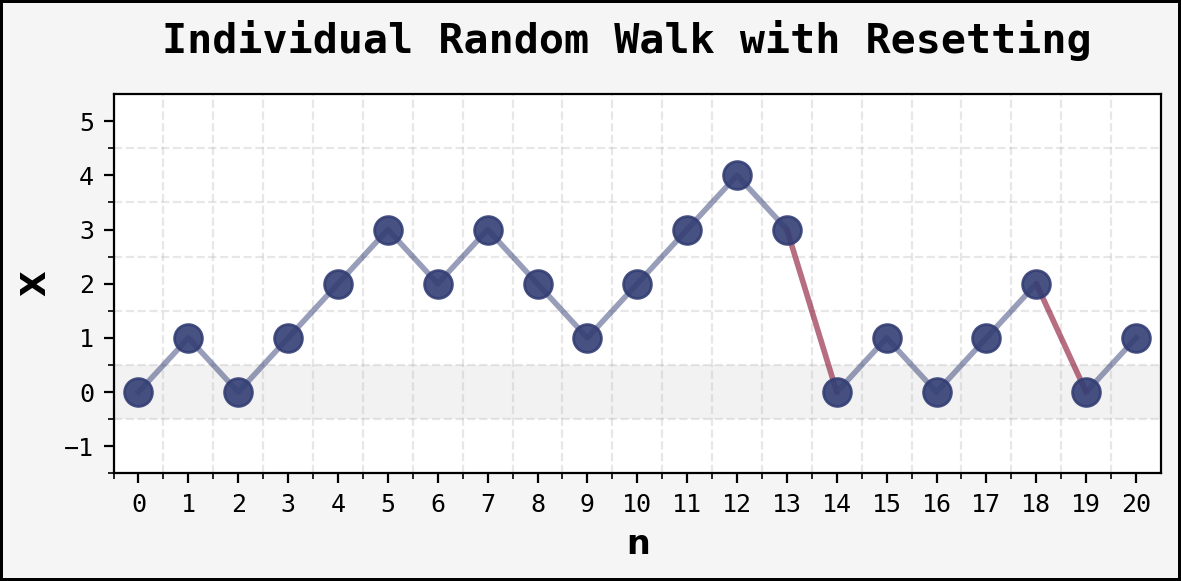

In [4]:
# You can change the probability of resetting!
complements.individual_resetting(0.1);

Now, if the relocation of the walker is done not to its initial position, but instead to one of the positions it has previously visited, we are allowing our walker to have <b>memory</b>. With this, the places it visits the most have more chances of being chosen when it jumps. This dynamic is implemented with a probability $\small \gamma$.

To visualize this, we do a random walk simulation with memory before actually showing it, so the walker we display has an existing distribution of visits beforehand.

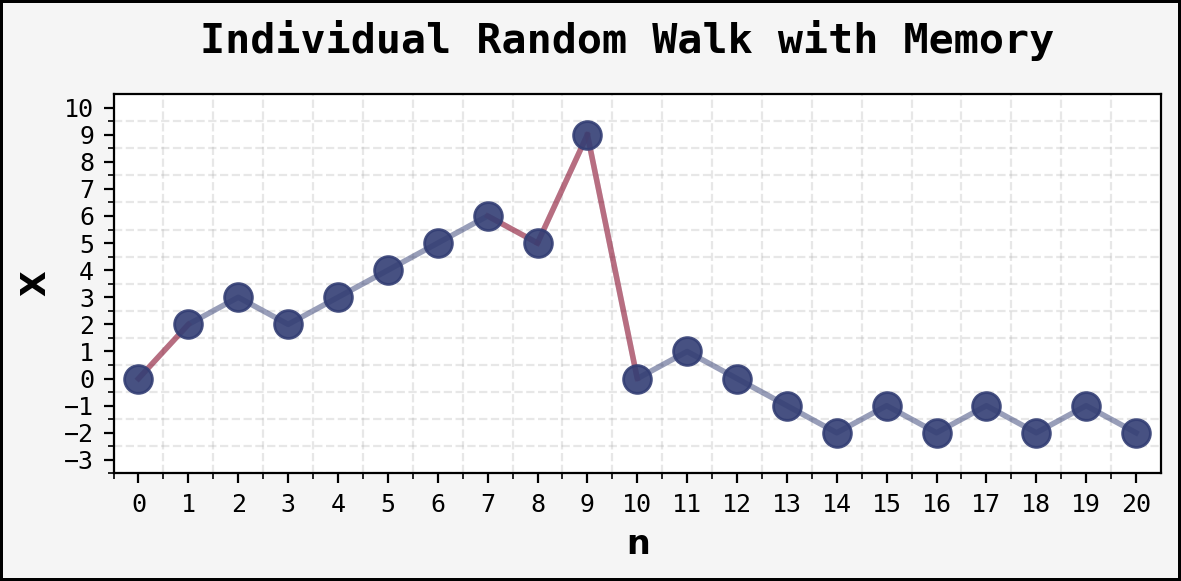

In [9]:
# You can change the probability of memory!
complements.individual_memory(0.2);

<head><link rel="stylesheet" href="complements/style.css"></head>

<h3 style="font-weight: bold; margin-bottom: 0;" id="simple">2. Simple Random Walk</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

In both discrete time and space, such as we saw in the <a class="ref-style" href="#individual"><b>Individual Random Walks</b></a>, the probability of finding the walker in the position $\small x$ at a given step $\small n$ is defined by the evolution equation

\begin{equation*}
    P(X,n+1) = \frac{1}{2} \, P(X+1,n) + \frac{1}{2} \, P(X-1,n)
\end{equation*}

We aim to study the random walk behavior in the continuous regime, for this, we need to consider the finite differences approximations to obtain a Partial Differential Equation:

\begin{equation*}
    \frac{\partial P(x,t)}{\partial t} \approx \frac{P(X,n+1) - P(X,n)}{\Delta n}, \qquad \frac{\partial^2 P(x,t)}{\partial x^2} \approx \frac{P(X+1,n) - 2 \, P(X,n) + P(X-1,n)}{\Delta X}
\end{equation*}

With this approximation, we change to the continuous variables $\small x,t$, and with some algebra, the equation that describes the Probability evolution becomes

\begin{equation*}
    \frac{\partial P(x,t)}{\partial t} = D \,\frac{\partial^2 P(x,t)}{\partial x^2}
\end{equation*}

with $\small D=1/2$. This is the <i>Diffusion Equation</i>, unsurprisingly for diffusive particles as one can think random walkers to be.

<a class="return-to-contents" href="#contents">◄ Return to Contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="simple:pos">2.1. Final Positions</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

The solution to the Diffusion equation is obtained by doing a variable change, using the Fourier transform: $\footnotesize \hat{P}(k,t) = \int P(x,t) \, {\rm exp}(-ikx)\, {\rm d}x$. The result is a Gaussian function:

\begin{equation*}
    P(x,t) = \frac{1}{\sqrt{2\pi(2Dt)}}\,e^{-(x-x_0)/2(2Dt)}
\end{equation*}

Here, we get some early results by comparing this to the normal distribution, for instance, the mean value is $\small \Mu = x_0$ ($\small 0$ in our case), and the variance is $\small \Mu_2 = 2Dt$. In the results, this function is a distribution of <b>Final Positions</b>, that is, the position where a walker can be found after a time $\small t$.

<img style="padding-top: 20px; width: 30%; display: block; margin: auto;" src="complements/diagrams/distribution.png">
<div class='caption'>Exemplification of how we measure the distribution of final positions at a certain time t=N.</div>

The rest of the statistical properties can be calculated from this function. Not surprisingly, for a symmetrical distribution, the skewness results in $\small \Mu_3 = 0$, and the kurtosis is that of the Gaussian Distribution, $\small \Mu_4 = 3$.


In [2]:
simplePositions = {};
simplePositions['Information'],simplePositions['Cases'],simplePositions['Distribution'],simplePositions['Variance'],\
simplePositions['Skewness'],simplePositions['Kurtosis'] = complements.reading_data('simple','position');

In [3]:
# VALUES DISPLAY
display(simplePositions['Information']);
print("\nCases:");
display(simplePositions['Cases'].transpose());
print("\nDistribution:");
display(simplePositions['Distribution'].iloc[simplePositions['Information']['MaxDistance'][1]-50:\
                                             simplePositions['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(simplePositions['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
simplePositions['NorDistribution'] = complements.normalization(simplePositions['Distribution'],simplePositions['Cases']);

,Cases,Realizations,MaxDistance,Time
1,3,100000,400,100



Cases:


,0,1,2
0,100,1000,10000



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,3.0,4.0,4.0,8.0,13.0,13.0,17.0,27.0,47.0,67.0,81.0,129.0,146.0,168.0,226.0,306.0,349.0,459.0,547.0,698.0,782.0,951.0,1129.0,1271.0,1496.0,1738.0,1907.0,2153.0,2410.0,2659.0,2941.0,3172.0,3227.0,3482.0,3683.0,3810.0,4038.0,3926.0,3975.0,3963.0,3862.0,3790.0,3732.0,3523.0,3289.0,3059.0,3008.0,2623.0,2426.0,2214.0,1919.0,1707.0,1454.0,1336.0,1126.0,916.0,787.0,691.0,548.0,431.0,346.0,270.0,215.0,175.0,129.0,112.0,65.0,75.0,34.0,33.0,21.0,16.0,6.0,14.0,5.0,3.0,3.0,4.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1000,349.0,395.0,395.0,418.0,458.0,467.0,497.0,519.0,533.0,585.0,535.0,577.0,594.0,636.0,700.0,653.0,699.0,779.0,707.0,814.0,779.0,830.0,810.0,898.0,890.0,936.0,970.0,969.0,1001.0,1037.0,998.0,1002.0,1059.0,1076.0,1124.0,1062.0,1166.0,1168.0,1194.0,1165.0,1177.0,1200.0,1284.0,1220.0,1241.0,1256.0,1254.0,1286.0,1236.0,1301.0,1242.0,1246.0,1254.0,1212.0,1210.0,1264.0,1225.0,1257.0,1261.0,1237.0,1236.0,1217.0,1216.0,1151.0,1117.0,1090.0,1152.0,1050.0,1072.0,1068.0,1040.0,1002.0,945.0,975.0,943.0,964.0,924.0,862.0,862.0,804.0,840.0,790.0,788.0,783.0,697.0,663.0,666.0,654.0,574.0,577.0,600.0,519.0,503.0,497.0,492.0,469.0,456.0,415.0,423.0,379.0
10000,372.0,361.0,386.0,374.0,383.0,359.0,355.0,368.0,380.0,380.0,394.0,382.0,366.0,385.0,334.0,348.0,359.0,378.0,376.0,399.0,406.0,336.0,403.0,392.0,357.0,405.0,390.0,377.0,366.0,361.0,338.0,418.0,387.0,358.0,390.0,413.0,384.0,417.0,388.0,381.0,401.0,417.0,391.0,382.0,403.0,431.0,401.0,407.0,414.0,389.0,406.0,390.0,411.0,396.0,408.0,445.0,430.0,389.0,397.0,425.0,387.0,350.0,401.0,411.0,381.0,397.0,381.0,406.0,381.0,395.0,418.0,388.0,387.0,399.0,382.0,383.0,393.0,351.0,410.0,378.0,369.0,365.0,383.0,356.0,411.0,380.0,388.0,395.0,349.0,367.0,349.0,355.0,365.0,345.0,370.0,367.0,323.0,361.0,342.0,338.0



Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
100,0.0,0.999998,1.997199,3.019025,4.028159,5.030550,6.029079,7.026301,8.037277,9.024654,10.021348,11.018705,11.998006,13.033831,14.020314,15.036517,16.056671,17.081915,18.083839,19.049913,20.069393,21.063936,22.078600,23.051918,24.067123,25.050238,26.033403,27.038029,28.055002,29.122200,30.133789,31.133600,32.149761,33.122284,34.148468,35.088478,36.115311,37.133431,38.100903,39.091133,40.073822,41.069824,42.056053,43.050838,44.089664,45.025997,46.070515,47.040623,48.010948,49.076889,50.044430,51.014977,51.974854,52.939480,53.986450,54.936314,55.858032,56.896500,57.852707,58.875843,59.759720,60.850548,61.855732,62.816326,63.812679,64.814369,65.811958,66.803215,67.739891,68.696533,69.646156,70.697372,71.707527,72.703323,73.675247,74.639694,75.607674,76.604912,77.593079,78.662361,79.644203,80.691498,81.719360,82.679306,83.692596,84.694916,85.699486,86.846405,87.827728,88.822014,89.820961,90.777435,91.765167,92.718399,93.687088,94.648598,95.647072,96.755592,97.833511,98.698669
1000,0.0,0.999995,1.997680,2.991588,3.980332,4.961843,5.972948,6.966137,7.983292,9.003718,10.029843,11.052340,12.083597,13.086668,14.062103,15.061781,16.068838,17.101397,18.070084,19.030714,19.990196,21.014446,22.007710,23.032934,24.045713,25.024956,25.984486,26.945679,27.958834,29.012400,30.060381,31.074133,32.097374,33.011120,34.033722,35.065895,36.044735,37.045795,38.016384,39.055584,39.991085,41.065155,42.110176,43.087910,44.090946,45.119327,46.129955,47.106670,48.127426,49.155819,50.144733,51.161320,52.175598,53.143425,54.140476,55.107811,56.127727,57.161835,58.207916,59.223152,60.221233,61.180244,62.216701,63.296875,64.294685,65.255508,66.194336,67.173111,68.257172,69.257179,70.254990,71.191429,72.180611,73.188904,74.312248,75.281250,76.257980,77.364250,78.334137,79.403320,80.353233,81.355225,82.456169,83.427406,84.426315,85.379402,86.438431,87.485016,88.402977,89.466362,90.462295,91.495377,92.493599,93.543274,94.482490,95.506691,96.502747,97.555527,98.471298,99.474457
10000,0.0,0.999997,2.008717,3.012716,4.011629,5.023911,6.015266,7.049803,8.034597,9.020621,10.012110,11.042866,12.012448,13.049985,14.026504,15.054468,16.059565,17.049213,18.049751,19.094160,20.123285,21.122143,22.164087,23.129953,24.120421,25.142633,26.110939,27.087711,28.081026,29.111103,30.141853,31.131571,32.164429,33.195396,34.208603,35.208652,36.253002,37.170750,38.171448,39.183228,40.178581,41.176353,42.103123,43.091503,44.088627,45.023003,46.008068,46.997578,47.995064,48.925343,49.961586,50.937878,51.903168,52.922783,53.922020,54.933788,56.045216,57.043358,58.089233,59.108868,60.122597,61.059380,62.038631,63.039974,64.004303,64.923523,65.836876,66.789932,67.787521,68.741516,69.697205,70.735809,71.856926,72.894699,73.961090,74.919945,75.987480,76.988953,77.929688,78.915733,79.926201,80.861260,81.814903,82.795853,83.897598,85.004669,86.078033,87.038307,88.105789,89.145607,90.217468,91.213913,92.267471,93.306160,94.465912,95.420563,96.358978,97.388763,98.338333,99.409103


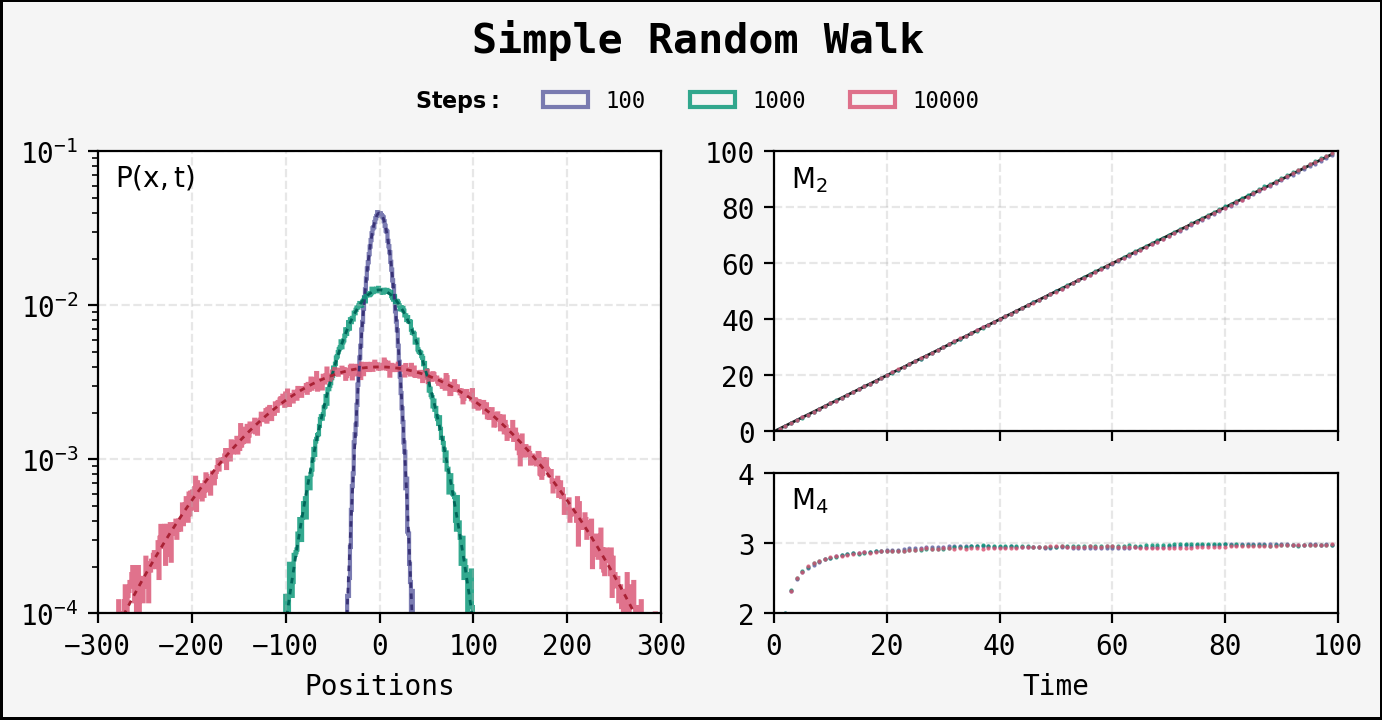

In [4]:
complements.distribution_simple_plotting('simple','position',simplePositions['NorDistribution'],simplePositions['Variance'],\
simplePositions['Kurtosis'],simplePositions['Cases'],simplePositions['Information'],[300,simplePositions['Information']['Time'][1]],\
[.1,100,2,4]);

<head><link rel="stylesheet" href="complements/style.css"></head>

All the simulation results follow a similar behavior to a Gaussian, only differing in the variance which increases linearly with time. Nevertheless, the statistical moments measured at equal times are the same. As we mentioned before, the kurtosis clearly indicates a distribution close to a Gaussian.

<a class="return-to-contents" href="#contents">◄ Return to contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="simple:vis">2.2. Visits</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

There is another type of distribution that collects all the information about the walkers' path. Instead of looking solely at the final positions, we can keep track of the visits the walkers pay to the positions. In a mathematical sense, this is similar to stacking all the distributions of final positions for different times, up to the time $\small t$.

\begin{equation*}
    \mathcal{P}(x,t) = \frac{1}{\mathcal{N}}\int _{0}^{t} P(x,t') \, {\rm d}t'
\end{equation*}

with $\small \mathcal{N}$ being the normalization constant. For the simple random walk, the integral yields

\begin{equation*}
    \mathcal{P}(x,t) = \frac{1}{\sqrt{D\pi t}} \, e^{-(x-x_0)^2 / 4Dt} - \frac{|x-x_0|}{2Dt}\, {\rm erfc} \left( \frac{|x-x_0|}{\sqrt{4Dt}} \right)
\end{equation*}

Here, $\small {\rm erfc}()$ is the complementary error function. In this case, the values of the statistical moments are not so intuitive, but they can be calculated with the PDF. For this case, the variance is just half of what we expect for the final positions, $\small \Mu_2 = Dt$. The kurtosis now has a value of $\small \Mu_4 = 4$, meaning more values are concentrated around the mean, naturally for the measurement of visits.

There is a change in how we measure the statistical moments, related to the normalization. When we only count the final positions of the walkers, to average the moments we just divide over the number of realizations $\small m$ (<a href="#about"><b>About</b></a>). However, by taking into account all the visits, we should also average over time:

\begin{equation*}
    \langle z^n \rangle = \frac{1}{t\,m} \sum_{j=0}^{t} \sum_{i=0}^{m} z_{ij}^{n}
\end{equation*}

Because of this condition, in the simulations, all realizations must be done at once, instead of starting the next one once the current is finished.

In [5]:
simpleVisits = {};
simpleVisits['Information'],simpleVisits['Cases'],simpleVisits['Distribution'],simpleVisits['Variance'],\
simpleVisits['Skewness'],simpleVisits['Kurtosis'] = complements.reading_data('simple','visits');

In [6]:
# VALUES DISPLAY
display(simpleVisits['Information']);
print("\nCases:");
display(simpleVisits['Cases'].transpose());
print("\nDistribution:");
display(simpleVisits['Distribution'].iloc[simpleVisits['Information']['MaxDistance'][1]-50:\
                                             simpleVisits['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(simpleVisits['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
simpleVisits['NorDistribution'] = complements.normalization(simpleVisits['Distribution'],simpleVisits['Cases']);

,Cases,Realizations,MaxDistance,Time
1,3,100000,400,100



Cases:


,0,1,2
0,100,1000,10000



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,6.0,5.0,2.0,9.0,19.0,33.0,51.0,108.0,154.0,245.0,362.0,565.0,719.0,1056.0,1388.0,2062.0,2720.0,3902.0,5088.0,7077.0,9070.0,12560.0,15972.0,21534.0,27298.0,36333.0,45205.0,58403.0,71998.0,91591.0,111221.0,138570.0,165123.0,201618.0,238502.0,287477.0,335479.0,395769.0,458335.0,534812.0,611671.0,706213.0,797979.0,704752.0,612786.0,536163.0,459487.0,397898.0,335568.0,286506.0,237619.0,200088.0,163673.0,137646.0,111413.0,92411.0,72922.0,59228.0,45501.0,36505.0,27654.0,21983.0,16022.0,12368.0,8913.0,6820.0,4819.0,3695.0,2626.0,1994.0,1310.0,1043.0,733.0,549.0,357.0,233.0,143.0,114.0,56.0,28.0,14.0,14.0,9.0,5.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0
1000,151870.0,164002.0,176037.0,189538.0,202524.0,216868.0,231595.0,248677.0,265590.0,285175.0,305291.0,328605.0,351176.0,374710.0,399071.0,426678.0,455279.0,487014.0,516146.0,547390.0,579236.0,614047.0,649296.0,690108.0,731608.0,776838.0,820581.0,865685.0,911523.0,961615.0,1013374.0,1069033.0,1124266.0,1181874.0,1238244.0,1301910.0,1367090.0,1433497.0,1499626.0,1574965.0,1647240.0,1722146.0,1798676.0,1882071.0,1962190.0,2045546.0,2133289.0,2225621.0,2318477.0,2420071.0,2520617.0,2422811.0,2325003.0,2231949.0,2138372.0,2054180.0,1967923.0,1882615.0,1800608.0,1722143.0,1644646.0,1572441.0,1499656.0,1433710.0,1366100.0,1301498.0,1237771.0,1180224.0,1121495.0,1065246.0,1010176.0,958845.0,907378.0,861738.0,816688.0,776058.0,734700.0,694037.0,653335.0,617441.0,582158.0,548870.0,515325.0,486131.0,456847.0,429766.0,402150.0,377921.0,354384.0,333076.0,311781.0,292980.0,274304.0,257804.0,240834.0,225762.0,210888.0,197367.0,184298.0,172610.0
10000,3967610.0,4031212.0,4098785.0,4165748.0,4226008.0,4288398.0,4352140.0,4416174.0,4478749.0,4545802.0,4614553.0,4687198.0,4760541.0,4832705.0,4904773.0,4973808.0,5042831.0,5113640.0,5180674.0,5250395.0,5320241.0,5393556.0,5470920.0,5549527.0,5626019.0,5707379.0,5795730.0,5882335.0,5961449.0,6040994.0,6125589.0,6216139.0,6307392.0,6395104.0,6475514.0,6559592.0,6649315.0,6737077.0,6828234.0,6923498.0,7010858.0,7100941.0,7191657.0,7282481.0,7367468.0,7452828.0,7549321.0,7649752.0,7747277.0,7851383.0,7956876.0,7857757.0,7754407.0,7652420.0,7551526.0,7458679.0,7365615.0,7270837.0,7174620.0,7077334.0,6986440.0,6898205.0,6809493.0,6724850.0,6634681.0,6542278.0,6457071.0,6378458.0,6296466.0,6209366.0,6119649.0,6036220.0,5953351.0,5874065.0,5796714.0,5719553.0,5638990.0,5556997.0,5480379.0,5405624.0,5327028.0,5249910.0,5174688.0,5099824.0,5022059.0,4953652.0,4886806.0,4815444.0,4748828.0,4682527.0,4615408.0,4552197.0,4483797.0,4414731.0,4346029.0,4282626.0,4221679.0,4160395.0,4098217.0,4032306.0



Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
100,0.0,0.5,1.000733,1.502549,2.001934,2.502985,3.001359,3.500668,4.002594,4.504159,5.008483,5.512224,6.012722,6.511704,7.010839,7.50998,8.008981,8.509903,9.012315,9.515267,10.018123,10.519933,11.022158,11.523571,12.024928,12.525783,13.025106,13.525689,14.026322,14.525614,15.025125,15.522621,16.020922,16.519314,17.018057,17.51642,18.013794,18.510664,19.008427,19.506771,20.004877,20.501638,20.999729,21.497124,21.993256,22.48905,22.983456,23.47822,23.972942,24.467676,24.962187,25.457041,25.951231,26.444801,26.939245,27.434519,27.928616,28.422016,28.915806,29.409498,29.9032,30.398306,30.893301,31.387362,31.881575,32.375244,32.870991,33.366878,33.863895,34.361435,34.858803,35.356323,35.853924,36.351417,36.849995,37.348663,37.847179,38.344982,38.843483,39.342587,39.840668,40.338406,40.836662,41.334415,41.831638,42.329086,42.826824,43.325115,43.823399,44.321293,44.819805,45.318821,45.817085,46.317402,46.818264,47.320049,47.822205,48.323746,48.825939,49.32896
1000,0.0,0.5,1.000733,1.502549,2.001934,2.502985,3.001359,3.500668,4.002594,4.504159,5.008483,5.512224,6.012722,6.511704,7.010839,7.50998,8.008981,8.509903,9.012315,9.515267,10.018123,10.519933,11.022158,11.523571,12.024928,12.525783,13.025106,13.525689,14.026322,14.525614,15.025125,15.522621,16.020922,16.519314,17.018057,17.51642,18.013794,18.510664,19.008427,19.506771,20.004877,20.501638,20.999729,21.497124,21.993256,22.48905,22.983456,23.47822,23.972942,24.467676,24.962187,25.457041,25.951231,26.444801,26.939245,27.434519,27.928616,28.422016,28.915806,29.409498,29.9032,30.398306,30.893301,31.387362,31.881575,32.375244,32.870991,33.366878,33.863895,34.361435,34.858803,35.356323,35.853924,36.351417,36.849995,37.348663,37.847179,38.344982,38.843483,39.342587,39.840668,40.338406,40.836662,41.334415,41.831638,42.329086,42.826824,43.325115,43.823399,44.321293,44.819805,45.318821,45.817085,46.317402,46.818264,47.320049,47.822205,48.323746,48.825939,49.32896
10000,0.0,0.5,1.000733,1.502549,2.001934,2.502985,3.001359,3.500668,4.002594,4.504159,5.008483,5.512224,6.012722,6.511704,7.010839,7.50998,8.008981,8.509903,9.012315,9.515267,10.018123,10.519933,11.022158,11.523571,12.024928,12.525783,13.025106,13.525689,14.026322,14.525614,15.025125,15.522621,16.020922,16.519314,17.018057,17.51642,18.013794,18.510664,19.008427,19.506771,20.004877,20.501638,20.999729,21.497124,21.993256,22.48905,22.983456,23.47822,23.972942,24.467676,24.962187,25.457041,25.951231,26.444801,26.939245,27.434519,27.928616,28.422016,28.915806,29.409498,29.9032,30.398306,30.893301,31.387362,31.881575,32.375244,32.870991,33.366878,33.863895,34.361435,34.858803,35.356323,35.853924,36.351417,36.849995,37.348663,37.847179,38.344982,38.843483,39.342587,39.840668,40.338406,40.836662,41.334415,41.831638,42.329086,42.826824,43.325115,43.823399,44.321293,44.819805,45.318821,45.817085,46.317402,46.818264,47.320049,47.822205,48.323746,48.825939,49.32896


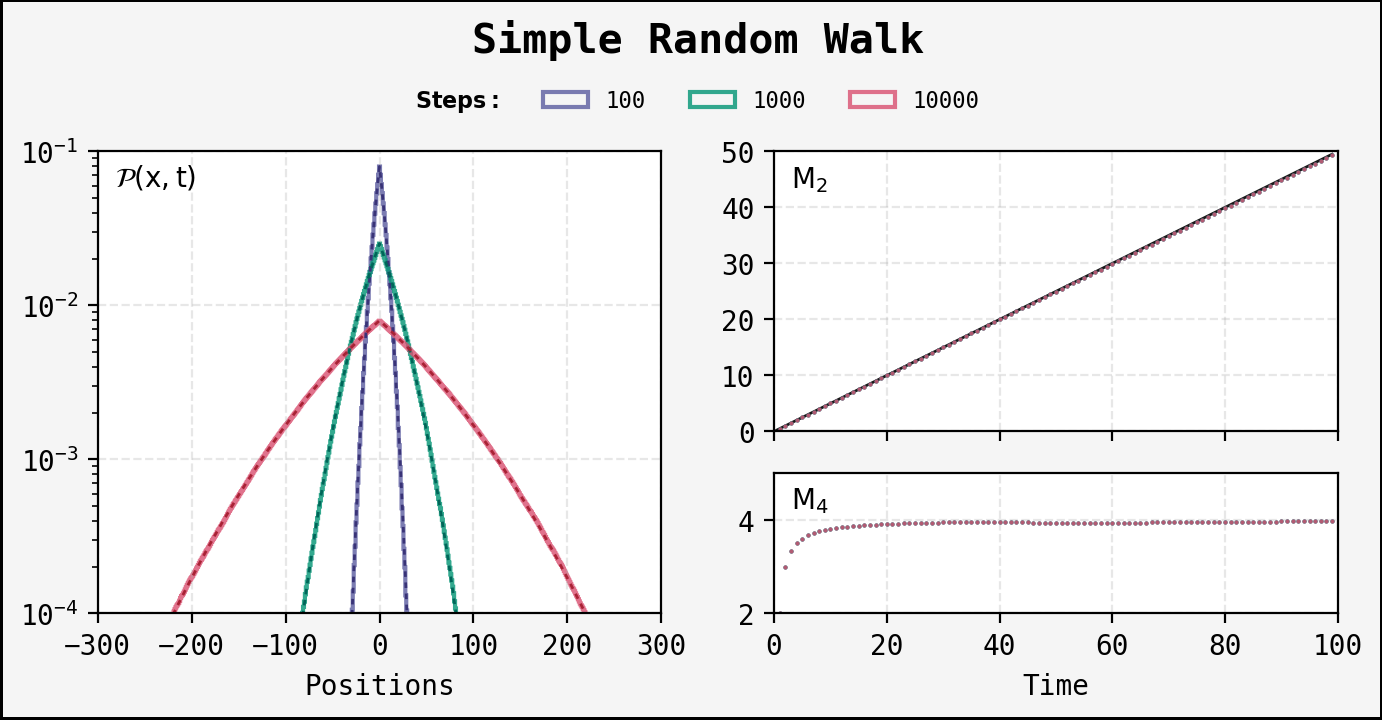

In [7]:
complements.distribution_simple_plotting('simple','visits',simpleVisits['NorDistribution'],simpleVisits['Variance'],\
simpleVisits['Kurtosis'],simpleVisits['Cases'],simpleVisits['Information'],[300,simpleVisits['Information']['Time'][1]],\
[.1,50,2,5]);

<head><link rel="stylesheet" href="complements/style.css"></head>

<a class="return-to-contents" href="#contents">◄ Return to contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h3 style="font-weight: bold; margin-bottom: 0;" id="resetting">3. Random Walk with Resetting</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

In the resetting case, a random walker not only hops to neighbor positions, but it has a probability $\small \gamma$ of returning to its initial position $\small x_0$. This limits the diffusion of the walker, that is how big the range of possible final positions is.

<img style="padding-top: 20px; padding-bottom:15px; width: 40%; display: block; margin: auto;" src="complements/diagrams/resetting_diagram.png">
<div class='caption'>Random walker movement schematics undergoing resetting dynamics.</div>

We can find a partial differential equation that describes the evolution of the PDF for the resetting case. Beginning from the Diffusion Equation, which defines the simple random walk dynamics, we use two new terms that implement the resetting. When a walker is reset, with probability $\small \gamma$, the PDF loses a flux of probability in the position $\small x$ that gets added to the initial position of the walker $\small x_0$, represented as a $\small \delta$ function (Evans M. & Majumdar S., 2011).

\begin{equation*}
    \frac{\partial P(x,t\,|\,x_0)}{\partial t} = D \,\frac{\partial^2 P(x,t\,|\,x_0)}{\partial x^2} {\color{red}- \gamma P(x,t\,|\,x_0)} {\color{royalblue}+ \gamma \delta(x-x_0)}
\end{equation*}

In this case, the diffusion constant $\small D$, is not the same as for the simple random walk. Empirically, we found that $\small D = (1-\gamma)/2$.

<a class="return-to-contents">◄ Return to contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="resetting:pos">3.1. Final Positions</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

This can be reduced to a stationary equation that becomes a non-homogeneous Ordinary Differential Equation. After solving this new equation, we obtain a time-independent solution.

\begin{equation*}
    P(x\,|\,x_0) = \frac{\alpha_0}{2} \, e^{-\alpha_0 |x-x_0|}
\end{equation*}

with ${\small \alpha_0 =} {\footnotesize \sqrt{2\gamma / (1-\gamma)}}$. In the same line, using the stationary solution we can obtain some results for the moments. For instance, the variance, also time-independent, has a value of $\small \Mu_2 = (1-\gamma)/\gamma$. The kurtosis shows a high value of $\small \Mu_4 = 6$, regardless of the resetting probability, indicating larger tails for these distributions.

In [2]:
resettingPositions = {};
resettingPositions['Information'],resettingPositions['Cases'],resettingPositions['Distribution'],resettingPositions['Variance'],\
resettingPositions['Skewness'],resettingPositions['Kurtosis'] = complements.reading_data('resetting','position');

In [3]:
# VALUES DISPLAY
display(resettingPositions['Information']);
print("\nCases:");
display(resettingPositions['Cases'].transpose());
print("\nDistribution:");
display(resettingPositions['Distribution'].iloc[resettingPositions['Information']['MaxDistance'][1]-50:\
                                             resettingPositions['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(resettingPositions['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
resettingPositions['NorDistribution'] = complements.normalization(resettingPositions['Distribution'],resettingPositions['Cases']);

,Cases,Realizations,Steps,MaxDistance,Time
1,4,100000,10000,400,1000



Cases:


,0,1,2,3
0,0.0,0.05,0.1,0.15



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0.00,347.0,361.0,350.0,349.0,379.0,368.0,322.0,363.0,381.0,354.0,352.0,365.0,368.0,404.0,358.0,378.0,369.0,373.0,406.0,403.0,389.0,362.0,387.0,378.0,408.0,361.0,390.0,372.0,360.0,382.0,404.0,377.0,370.0,377.0,416.0,389.0,401.0,395.0,419.0,381.0,396.0,404.0,372.0,362.0,376.0,380.0,378.0,390.0,409.0,426.0,404.0,381.0,438.0,433.0,423.0,385.0,405.0,413.0,404.0,416.0,392.0,390.0,395.0,398.0,392.0,363.0,355.0,387.0,389.0,429.0,368.0,388.0,395.0,401.0,378.0,386.0,394.0,394.0,369.0,393.0,422.0,356.0,378.0,401.0,351.0,362.0,368.0,372.0,373.0,357.0,361.0,383.0,341.0,372.0,403.0,384.0,357.0,346.0,349.0,331.0
0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,4.0,3.0,4.0,6.0,11.0,10.0,18.0,17.0,29.0,42.0,73.0,91.0,121.0,199.0,232.0,331.0,443.0,617.0,901.0,1185.0,1678.0,2273.0,3257.0,4457.0,6119.0,8524.0,11376.0,16185.0,11350.0,8506.0,6148.0,4301.0,3093.0,2393.0,1642.0,1238.0,850.0,653.0,440.0,313.0,271.0,173.0,95.0,91.0,62.0,51.0,33.0,22.0,15.0,13.0,7.0,8.0,10.0,0.0,1.0,2.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,3.0,1.0,4.0,7.0,12.0,12.0,29.0,30.0,38.0,83.0,127.0,201.0,325.0,605.0,886.0,1434.0,2223.0,3532.0,5764.0,8845.0,14286.0,22848.0,14502.0,8989.0,5596.0,3607.0,2286.0,1395.0,854.0,538.0,364.0,204.0,146.0,70.0,57.0,34.0,22.0,13.0,8.0,9.0,2.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,3.0,9.0,10.0,20.0,52.0,102.0,151.0,245.0,479.0,837.0,1524.0,2610.0,4882.0,8956.0,15750.0,28632.0,15841.0,8783.0,4935.0,2775.0,1482.0,864.0,436.0,301.0,146.0,67.0,52.0,24.0,12.0,4.0,8.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0.00,0.0,1.000000,2.010706,3.022407,4.018400,5.003377,6.011006,6.976624,8.017498,9.020086,10.006761,10.994330,12.035328,13.022509,13.991931,15.028053,16.001650,17.050484,18.073820,19.062868,20.073507,21.089958,22.105347,23.098928,24.094828,25.077156,26.113560,27.137968,28.099028,29.085621,30.095524,31.075253,32.085011,33.118141,34.139011,35.176468,36.119705,37.221722,38.221600,39.175297,40.234802,41.230312,42.345676,43.249813,44.249901,45.171596,46.191265,47.149101,48.150780,49.125164,50.147190,51.161583,52.130871,53.084740,54.055450,55.134754,56.148476,57.169010,58.131222,59.115608,60.059269,61.035248,62.018398,62.992645,63.938740,64.834625,65.812736,66.823013,67.852028,68.776650,69.783112,70.774406,71.890541,72.817459,73.839920,74.832977,75.730629,76.731690,77.689171,78.659790,79.634537,80.623680,81.552902,82.530914,83.492737,84.573341,85.654182,86.663307,87.712372,88.764549,89.795532,90.777168,91.694809,92.760376,93.866539,94.876129,95.860069,96.835709,97.853203,98.885345
0.05,0.0,0.949595,1.866539,2.713963,3.512153,4.269118,4.993150,5.693488,6.371908,7.013211,7.616855,8.169128,8.703658,9.229601,9.738696,10.165849,10.614009,11.021982,11.430110,11.789812,12.150391,12.449069,12.706645,13.062980,13.390233,13.643161,13.911863,14.156116,14.360387,14.578428,14.837141,15.025424,15.174425,15.340534,15.518439,15.666306,15.794887,15.966975,16.157024,16.324953,16.429949,16.576563,16.694681,16.794498,16.952581,17.053947,17.162889,17.207369,17.322743,17.387672,17.486982,17.518652,17.572296,17.645641,17.701353,17.750124,17.769081,17.819857,17.853504,17.971214,18.024721,18.081877,18.141684,18.219303,18.222368,18.216990,18.270004,18.277298,18.271892,18.313150,18.385094,18.398676,18.380190,18.490805,18.484610,18.443525,18.510983,18.475424,18.555962,18.563354,18.588356,18.658455,18.674236,18.697550,18.707876,18.742600,18.723253,18.752834,18.745571,18.774921,18.812378,18.829416,18.866837,18.868555,18.902220,18.887898,18.946516,19.002468,19.014898,19.034058
0.10,0.0,0.900210,1.713469,2.444640,3.109980,3.698784,4.222833,4.712628,5.144678,5.548379,5.909114,6.212254,6.482669,6.734940,6.952441,7.130906,7.314676,7.484338,7.622537,7.777539,7.891178,8.002191,8.092563,8.185738,8.254269,8.315182,8.426716,8.514430,8.585547,8.619235,8.648479,8.627359,8.670541,8.701495,8.703853,8.732911,8.763428,8.796947,8.870602,8.837128,8.848154,8.864712,8.893151,8.937284,8.960077,8.960505,8.954777,8.978377,9.020021,9.004780,8.993820,8.987425,9.006908,8.990826,8.947216,8.924984,8.941452,8.967027,8.944443,8.936816,9.013201,9.020174,9.047932,9.007923,8.998722,9.000552,9.000867,8.971592,8.997433,9.014005,8.985251,8.986779,9.022063,8.985839,8.997628,9.020512,9.041193,9.039370,9.013167,9.006512,8.983914,8.998450,9.001800,9.031387,9.004375,8.993463,8.953003,8.939192,8.863984,8.826378,8.837135,8.847778,8.851234,8.853971,8.910602,8.938302,8.940689,8.950832,8.951803,8.937822
0.15,0.0,0.851155,1.574538,2.184069,2.717345,3.145550,3.529552,3.824374,4.097066,4.340155,4.532665,4.679974,4.793619,4.933437,5.058438,5.126990,5.180326,5.254810,5.329737,5.377111,5.423283,5.485798,5.476318,5.500124,5.499526,5.514138,5.526536,5.580955,5.575647,5.558531,5.582628,5.596812,5.580750,5.595587,5.586580,5.587860,5.610236,5.642126,5.645324,5.642778,5.639253,5.635586,5.626379,5.610479,5.570704,5.611594,5.646040,5.692640,5.733559,5.725251,5.727489,5.738822,5.701579,5.715527,5.643926,5.662144,5.677373,5.668066,5.679688,5.660140,5.647379,5.651106,5.640770,5.662416,5.685805,5.685385,5.664337,5.663382,5.657457,5.643598,5.645052,5.654742,5.640490,5.677751,5.661050,5.666889,5.669700,5.691051,5.649002,5.649398,5.656874,5.672188,5.664257,5.634457,5.614897,5.623330,5.644795,5.663019,5.647037,5.648431,5.645507,5.650844,5.6393

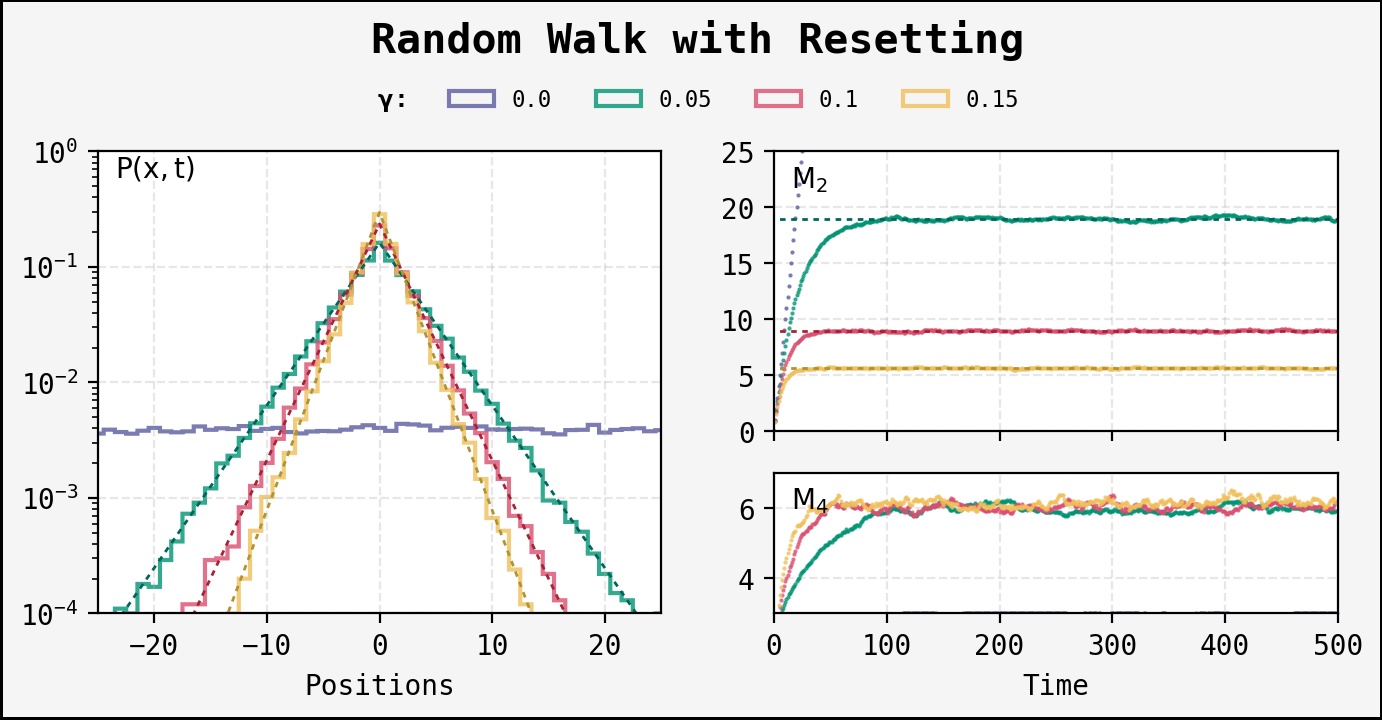

In [4]:
complements.distribution_probability_plotting('resetting','position',resettingPositions['NorDistribution'],resettingPositions['Variance'],\
resettingPositions['Kurtosis'],resettingPositions['Cases'],resettingPositions['Information'],[25,\
resettingPositions['Information']['Time'][1]/2],[1,25,3,7]);

<head><link rel="stylesheet" href="complements/style.css"></head>

The resetting is one of the most remarkable models of the random walk. The variance indicates the existent difficulty to reach new positions, and we could even think walkers are caged inside a specific range.

<a class="return-to-contents" href="#contents">◄ Return to contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="resetting:vis">3.2. Visits</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

Something interesting happens when we try to find the PDF for the visits. If we use our stationary solution we get the same result, as its independence of time yields $\small t$ as both the result of the integral and the normalization constant. And the simulations suggest there is not a big change in the dynamics.

In [5]:
resettingVisits = {};
resettingVisits['Information'],resettingVisits['Cases'],resettingVisits['Distribution'],resettingVisits['Variance'],\
resettingVisits['Skewness'],resettingVisits['Kurtosis'] = complements.reading_data('resetting','visits');

In [6]:
# VALUES DISPLAY
display(resettingVisits['Information']);
print("\nCases:");
display(resettingVisits['Cases'].transpose());
print("\nDistribution:");
display(resettingVisits['Distribution'].iloc[resettingVisits['Information']['MaxDistance'][1]-50:\
                                             resettingVisits['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(resettingVisits['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
resettingVisits['NorDistribution'] = complements.normalization(resettingVisits['Distribution'],resettingVisits['Cases']);

,Cases,Realizations,Steps,MaxDistance,Time
1,4,100000,10000,400,1000



Cases:


,0,1,2,3
0,0.0,0.05,0.1,0.15



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0.00,3939981.0,4007084.0,4066819.0,4125584.0,4185687.0,4249460.0,4315155.0,4379188.0,4437650.0,4500047.0,4566813.0,4635450.0,4705459.0,4776712.0,4847821.0,4919622.0,4992414.0,5069680.0,5150527.0,5231369.0,5305916.0,5381711.0,5458331.0,5536695.0,5612715.0,5688499.0,5768531.0,5855627.0,5938341.0,6015995.0,6096548.0,6185445.0,6279874.0,6372790.0,6459737.0,6549467.0,6643525.0,6737222.0,6824594.0,6917378.0,7017674.0,7119939.0,7217961.0,7313830.0,7405981.0,7499316.0,7593814.0,7691973.0,7793814.0,7898054.0,8002172.0,7908229.0,7810031.0,7711575.0,7615214.0,7517737.0,7420551.0,7326016.0,7233291.0,7141783.0,7046925.0,6952198.0,6860502.0,6777601.0,6693706.0,6606164.0,6515034.0,6424507.0,6337967.0,6256522.0,6173612.0,6087328.0,6001578.0,5918761.0,5838062.0,5757392.0,5675060.0,5594724.0,5514556.0,5435365.0,5351928.0,5273884.0,5200134.0,5124931.0,5050867.0,4980999.0,4908613.0,4840122.0,4773787.0,4708115.0,4647713.0,4582835.0,4512227.0,4447941.0,4378957.0,4311310.0,4244264.0,4177161.0,4112844.0,4051727.0
0.05,2.0,3.0,12.0,37.0,64.0,66.0,86.0,127.0,183.0,257.0,313.0,453.0,729.0,1053.0,1409.0,1947.0,2665.0,3733.0,5244.0,7191.0,9873.0,13748.0,18937.0,26022.0,35901.0,49479.0,68332.0,94246.0,130198.0,179418.0,247863.0,343026.0,474501.0,656024.0,904922.0,1249970.0,1729839.0,2394983.0,3312585.0,4572092.0,6314333.0,8725915.0,12060575.0,16667032.0,23029491.0,31819145.0,43970084.0,60756306.0,83947821.0,115993443.0,160272717.0,115991418.0,83936893.0,60753259.0,43977227.0,31833853.0,23039145.0,16671818.0,12066817.0,8735384.0,6326339.0,4581198.0,3313462.0,2398100.0,1734925.0,1256394.0,910522.0,659217.0,475737.0,343700.0,249088.0,180423.0,130482.0,94827.0,68569.0,49358.0,35607.0,25630.0,18417.0,13159.0,9521.0,6951.0,5087.0,3774.0,2684.0,1875.0,1354.0,993.0,725.0,477.0,311.0,232.0,179.0,127.0,87.0,72.0,54.0,37.0,24.0,18.0
0.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,15.0,21.0,32.0,50.0,67.0,99.0,172.0,298.0,491.0,728.0,1131.0,1827.0,2959.0,4751.0,7816.0,12805.0,20342.0,32014.0,50757.0,80772.0,128710.0,205975.0,329469.0,526581.0,842484.0,1343173.0,2144143.0,3424436.0,5463453.0,8714006.0,13901691.0,22178214.0,35374718.0,56461010.0,90120426.0,143821629.0,229519441.0,143840660.0,90143955.0,56480573.0,35393082.0,22181738.0,13898824.0,8709747.0,5458674.0,3420458.0,2142619.0,1344836.0,844579.0,529421.0,332207.0,207889.0,130566.0,82193.0,51788.0,32700.0,20868.0,13358.0,8279.0,5295.0,3399.0,2121.0,1354.0,794.0,458.0,293.0,179.0,117.0,80.0,64.0,53.0,39.0,20.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,8.0,10.0,15.0,29.0,61.0,119.0,225.0,375.0,678.0,1256.0,2266.0,4183.0,7507.0,13451.0,24193.0,43721.0,78301.0,139759.0,251295.0,452400.0,813486.0,1461331.0,2627599.0,4718077.0,8472254.0,15218666.0,27343035.0,49122075.0,88246951.0,158532321.0,284816119.0,158537922.0,88252228.0,49120366.0,27340368.0,15222619.0,8479005.0,4724185.0,2631720.0,1465103.0,814420.0,452344.0,251583.0,140308.0,78484.0,43647.0,23936.0,13300.0,7608.0,4186.0,2163.0,1157.0,637.0,390.0,250.0,136.0,74.0,41.0,23.0,13.0,8.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0.00,0.0,0.499998,0.999813,1.500340,2.000656,2.501318,3.001943,3.503675,4.003186,4.500696,4.999837,5.498401,5.999157,6.500916,7.001399,7.501804,8.004213,8.505014,9.003880,9.504139,10.004058,10.503171,11.002496,11.502705,12.001956,12.500676,12.997144,13.492876,13.989553,14.485855,14.981671,15.477503,15.973440,16.472212,16.971111,17.470352,17.968496,18.469463,18.969040,19.468941,19.970381,20.470512,20.971209,21.471861,21.973581,22.476181,22.978882,23.481331,23.983997,24.487160,24.990080,25.493286,25.997589,26.501484,27.005516,27.509062,28.011482,28.513870,29.016006,29.517208,30.018095,30.518749,31.019279,31.520658,32.022930,32.524086,33.025886,33.527016,34.028580,34.529591,35.029907,35.529644,36.029442,36.529625,37.030270,37.529911,38.030052,38.529705,39.029457,39.529419,40.028419,40.526474,41.024235,41.521347,42.018829,42.516247,43.013199,43.510231,44.009121,44.508690,45.009075,45.509296,46.010075,46.510006,47.009876,47.509808,48.009544,48.509315,49.009659,49.509815
0.05,0.0,0.475110,0.937333,1.383645,1.813429,2.229713,2.631244,3.018117,3.392975,3.755558,4.106168,4.443944,4.771988,5.090543,5.398952,5.700775,5.992903,6.275773,6.548676,6.812882,7.067951,7.316568,7.556780,7.788579,8.012589,8.228849,8.438982,8.642653,8.840041,9.032285,9.218946,9.400992,9.576867,9.747858,9.913194,10.074042,10.230116,10.382072,10.530790,10.674576,10.814850,10.953410,11.087168,11.217476,11.343012,11.465523,11.583818,11.700160,11.812957,11.922861,12.029599,12.134163,12.235817,12.335172,12.432673,12.528653,12.621479,12.711753,12.800765,12.888280,12.974250,13.058001,13.139937,13.219569,13.297274,13.373805,13.447836,13.520356,13.591947,13.661280,13.728211,13.793580,13.857677,13.920258,13.980968,14.040780,14.099388,14.156540,14.211854,14.266467,14.319568,14.370311,14.420053,14.468919,14.517792,14.566145,14.613793,14.659993,14.705579,14.750996,14.795490,14.840076,14.883635,14.925721,14.966867,15.006706,15.045686,15.084323,15.122124,15.159200
0.10,0.0,0.450824,0.870747,1.264945,1.633514,1.975615,2.295177,2.595096,2.873152,3.133762,3.378472,3.610593,3.829834,4.038159,4.234916,4.420524,4.596850,4.762087,4.918894,5.064985,5.203017,5.333415,5.456890,5.574213,5.685151,5.790519,5.890890,5.987275,6.077544,6.163550,6.245085,6.322303,6.394491,6.463413,6.528919,6.591277,6.651407,6.708745,6.764445,6.818255,6.869581,6.918846,6.965327,7.009728,7.053385,7.095061,7.135021,7.172213,7.208079,7.242032,7.274689,7.306800,7.337960,7.368015,7.397276,7.425908,7.453460,7.479918,7.505313,7.529843,7.553727,7.576815,7.599271,7.620743,7.641832,7.662625,7.682580,7.702306,7.721752,7.740734,7.759253,7.777706,7.795576,7.813526,7.830276,7.846855,7.862975,7.878389,7.893179,7.907398,7.921427,7.935106,7.948365,7.960971,7.973309,7.985308,7.996807,8.008234,8.019901,8.030804,8.041997,8.052957,8.063446,8.074100,8.084405,8.094606,8.104630,8.114236,8.123317,8.132473
0.15,0.0,0.425790,0.809026,1.153704,1.462492,1.742525,1.995950,2.226508,2.434148,2.625778,2.802256,2.965006,3.112830,3.246780,3.370109,3.483365,3.587903,3.684795,3.774239,3.857394,3.934497,4.005518,4.072384,4.134270,4.192985,4.248407,4.300700,4.348659,4.393427,4.434953,4.473643,4.511166,4.546474,4.579254,4.610098,4.639670,4.667416,4.693241,4.718358,4.741779,4.763787,4.784327,4.804683,4.824482,4.842717,4.860196,4.876840,4.892619,4.907600,4.922134,4.936370,4.950144,4.963245,4.976017,4.988677,5.000154,5.010706,5.020745,5.030780,5.040195,5.049301,5.057928,5.066728,5.075445,5.083509,5.091214,5.098882,5.106256,5.113091,5.119965,5.126762,5.133403,5.139709,5.146474,5.153030,5.159659,5.166473,5.173215,5.179652,5.186111,5.192486,5.198639,5.204865,5.210546,5.215862,5.220768,5.225677,5.230236,5.234839,5.239676,5.244096,5.248701,5.252951,5.257103,5.261386,5.265984,

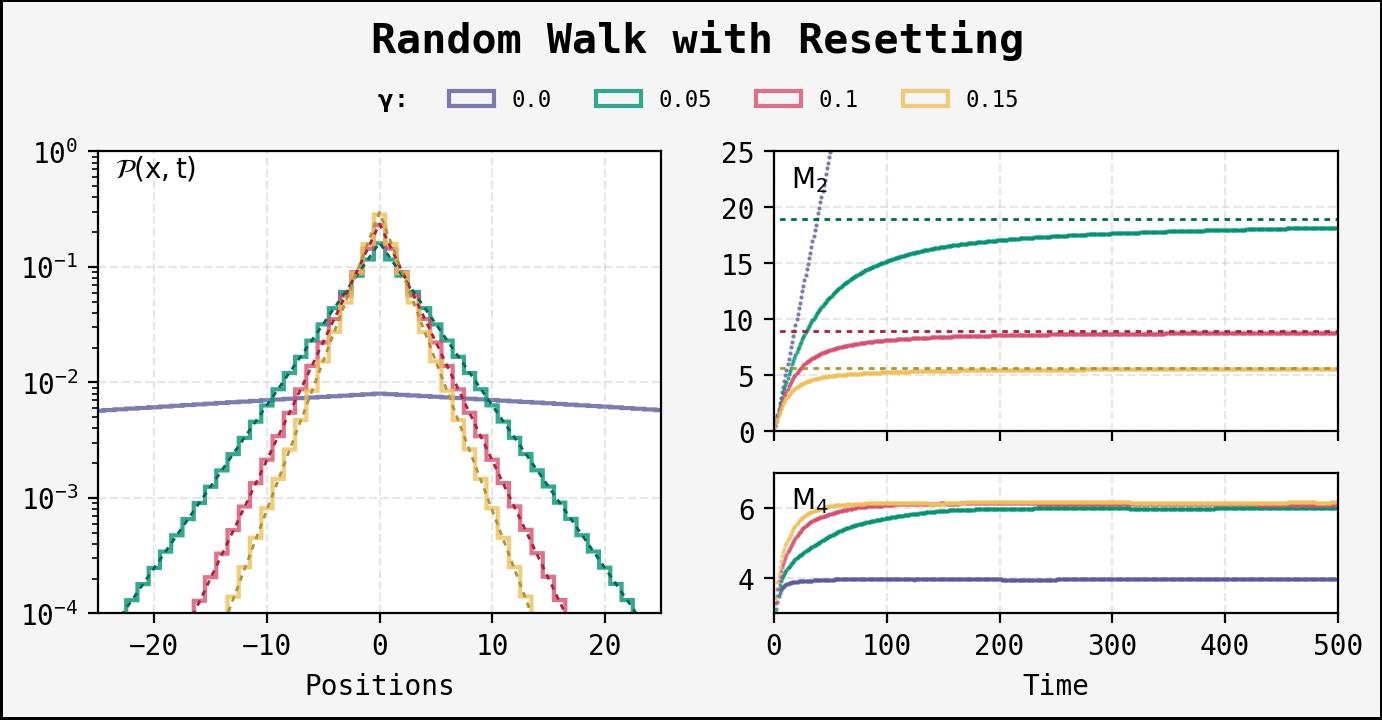

In [7]:
complements.distribution_probability_plotting('resetting','visits',resettingVisits['NorDistribution'],resettingVisits['Variance'],\
resettingVisits['Kurtosis'],resettingVisits['Cases'],resettingVisits['Information'],[25,resettingVisits['Information']['Time'][1]/2],\
[1,25,3,7]);

<head><link rel="stylesheet" href="complements/style.css"></head>

By looking at the distribution and the statistical properties, we can see that this case is close to time-independent. Why "close"? The small amount of data in the final positions, in comparison with the visits, gives us a variance result that might not show the full picture. Here, the kurtosis and the PDF are the same as before, but there is a difference in the variance produced by a better resolution of data. This new perspective indicates an asymptotic behavior that tends to the value we calculated theoretically using the stationary solution, but the stochastic effects on the resetting dynamics, that is, the probability of resetting, allows walkers to get to new positions with enough time.

<a class="return-to-contents" href="#contents">◄ Return to contents</a>

<head><link rel="stylesheet" href="complements/style.css"></head>

<h3 style="font-weight: bold; margin-bottom: 0;" id="memory">4. Random Walk with Memory</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

This case also allows walkers' relocation besides the normal step, but instead of placing the walker in a defined position, this is chosen according to a probability distribution of all the visited sites up to that point.

<img style="padding-top: 20px; padding-bottom:15px; width: 40%; display: block; margin: auto;" src="complements/diagrams/memory_diagram.png">
<div class='caption'>Random walker movement schematics undergoing memory dynamics.</div>

We can write a differential equation for this case, similar to resetting. In the same sense, we have a negative flux of probability coming out of the $\small x$ position, however, this is added into a term that represents the visits distribution instead of a single position (Boyer D. & Solis-Salas C., 2014).

\begin{equation*}
    \frac{\partial P(x,t)}{\partial t} = D \,\frac{\partial^2 P(x,t)}{\partial x^2} {\color{red}- \gamma P(x,t)} {\color{royalblue}+ \frac{\gamma}{t} \int_{0}^{t} P(x,t')\, {\rm d}t'}
\end{equation*}

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="memory:pos">4.1. Final Positions</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

We cannot get an analytical expression for the PDF, nevertheless, we can turn the last equation incognita into the second moment, only time-dependent. This is done by applying the definition of the statistical moments we discussed at the beginning of this document in the <a class="ref-style" href=#about><b>About</b></a> section; after which we apply a time derivative to remove the integral.

\begin{equation*}
    t \frac{{\rm d}^2\mu_2(t)}{{\rm d}t^2} + (1+\gamma) \frac{{\rm d}\mu_2(t)}{{\rm d}t} = 2D
\end{equation*}

Due to the symmetrical nature of the phenomena, one can anticipate the average to be zero, thus we can assume the solution to apply to the variance $\small M_2$:

\begin{equation*}
    \Mu_2(t) = \frac{2D}{\gamma}[{\rm E_1}(\gamma t) + \ln(\gamma t)+\gamma_e]
\end{equation*}

Here, $\small {\rm E_1}$ is an Exponential Integral function and $\small \gamma_e$ is the Euler's constant. We can try to make an approximation to the simulated PDF by using the Gaussian equation, changing the variance for the value of $\small \Mu_2(t)$.

In [2]:
memoryPositions = {};
memoryPositions['Information'],memoryPositions['Cases'],memoryPositions['Distribution'],memoryPositions['Variance'],\
memoryPositions['Skewness'],memoryPositions['Kurtosis'] = complements.reading_data('memory','position');

In [3]:
# VALUES DISPLAY
display(memoryPositions['Information']);
print("\nCases:");
display(memoryPositions['Cases'].transpose());
print("\nDistribution:");
display(memoryPositions['Distribution'].iloc[memoryPositions['Information']['MaxDistance'][1]-50:\
                                             memoryPositions['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(memoryPositions['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
memoryPositions['NorDistribution'] = complements.normalization(memoryPositions['Distribution'],memoryPositions['Cases']);

,Cases,Realizations,Steps,MaxDistance,Time
1,4,100000,10000,400,1000



Cases:


,0,1,2,3
0,0.0,0.05,0.1,0.15



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0.00,342.0,362.0,355.0,349.0,361.0,349.0,394.0,356.0,376.0,361.0,382.0,344.0,364.0,381.0,366.0,398.0,378.0,389.0,400.0,394.0,394.0,401.0,397.0,392.0,355.0,333.0,390.0,375.0,393.0,393.0,400.0,380.0,420.0,380.0,386.0,387.0,416.0,418.0,360.0,429.0,375.0,355.0,398.0,406.0,403.0,395.0,348.0,409.0,368.0,390.0,435.0,395.0,446.0,379.0,425.0,430.0,418.0,407.0,402.0,449.0,386.0,393.0,369.0,390.0,353.0,374.0,396.0,387.0,372.0,387.0,370.0,401.0,377.0,426.0,352.0,389.0,401.0,371.0,369.0,410.0,379.0,391.0,394.0,393.0,391.0,347.0,395.0,367.0,364.0,336.0,363.0,359.0,351.0,361.0,376.0,379.0,360.0,397.0,355.0,319.0
0.05,1.0,6.0,7.0,3.0,10.0,6.0,10.0,13.0,9.0,17.0,14.0,36.0,26.0,40.0,36.0,50.0,58.0,87.0,100.0,107.0,108.0,145.0,185.0,221.0,264.0,298.0,341.0,411.0,494.0,525.0,667.0,823.0,832.0,1024.0,1146.0,1330.0,1525.0,1691.0,1834.0,2066.0,2252.0,2464.0,2743.0,3002.0,3115.0,3432.0,3504.0,3624.0,3653.0,3844.0,3912.0,3721.0,3758.0,3683.0,3517.0,3379.0,3124.0,2885.0,2780.0,2398.0,2204.0,2113.0,1908.0,1596.0,1507.0,1282.0,1111.0,966.0,910.0,750.0,658.0,513.0,489.0,406.0,346.0,325.0,239.0,258.0,159.0,161.0,124.0,92.0,80.0,55.0,70.0,50.0,37.0,49.0,31.0,34.0,22.0,21.0,12.0,7.0,9.0,8.0,5.0,5.0,7.0,3.0
0.10,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,3.0,2.0,3.0,11.0,8.0,17.0,7.0,25.0,23.0,35.0,41.0,60.0,72.0,94.0,129.0,155.0,191.0,270.0,344.0,409.0,543.0,713.0,855.0,1017.0,1182.0,1503.0,1681.0,2118.0,2375.0,2802.0,3212.0,3580.0,4131.0,4418.0,4807.0,5118.0,5256.0,5389.0,5370.0,4994.0,4748.0,4442.0,4099.0,3640.0,3219.0,2794.0,2521.0,2066.0,1770.0,1454.0,1244.0,1025.0,812.0,634.0,532.0,440.0,360.0,287.0,221.0,179.0,133.0,107.0,77.0,48.0,48.0,27.0,27.0,16.0,14.0,10.0,5.0,9.0,6.0,5.0,4.0,1.0,2.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
0.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,4.0,10.0,8.0,6.0,13.0,27.0,24.0,45.0,55.0,73.0,111.0,131.0,198.0,245.0,352.0,486.0,627.0,793.0,1053.0,1361.0,1749.0,2138.0,2591.0,3207.0,3745.0,4494.0,5189.0,5529.0,6190.0,6422.0,6522.0,6336.0,6181.0,5659.0,5020.0,4277.0,3790.0,3151.0,2573.0,2189.0,1773.0,1357.0,1053.0,801.0,639.0,462.0,360.0,275.0,192.0,136.0,114.0,90.0,50.0,35.0,24.0,22.0,14.0,14.0,2.0,5.0,2.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0.00,0.0,0.999986,1.997893,2.990149,3.992297,4.976807,5.978837,6.954319,7.946397,8.945347,9.944520,10.953261,11.957667,12.970061,14.003635,15.009918,15.972400,16.953838,17.926359,18.923838,19.890959,20.911762,21.898422,22.863598,23.870436,24.848282,25.836401,26.822630,27.821203,28.824637,29.831800,30.854715,31.826595,32.820465,33.796303,34.865200,35.880859,36.835438,37.842857,38.881283,39.862957,40.847576,41.829140,42.742195,43.792236,44.776733,45.722515,46.724712,47.742764,48.729832,49.734314,50.810631,51.802940,52.769661,53.783661,54.861053,55.812149,56.819378,57.806202,58.888603,59.844688,60.877567,61.878002,62.896137,63.880100,64.805290,65.830193,66.815124,67.871826,68.860100,69.863380,70.885727,71.914032,72.850723,73.767227,74.864067,75.917488,76.939583,77.920151,78.962868,79.869309,80.795578,81.765015,82.804970,83.768402,84.804962,85.755806,86.716667,87.751663,88.694076,89.698807,90.770393,91.778496,92.746063,93.722603,94.748161,95.668945,96.674263,97.647583,98.695152
0.05,0.0,0.948960,1.875969,2.785719,3.671943,4.541725,5.365706,6.172420,6.976730,7.755721,8.517933,9.271099,9.994978,10.695511,11.402361,12.075399,12.739960,13.378016,13.994780,14.652395,15.284837,15.859707,16.386806,16.968142,17.557400,18.079413,18.645367,19.100834,19.593275,20.058676,20.640480,21.156208,21.602594,22.122381,22.548283,22.994738,23.390469,23.836695,24.288996,24.787565,25.216736,25.607025,26.023974,26.469458,26.914864,27.389259,27.740099,28.159943,28.476339,28.709442,29.140310,29.417582,29.729385,30.105122,30.484774,30.831581,31.124899,31.344961,31.634788,31.900557,32.184639,32.472920,32.778072,33.027775,33.284004,33.438705,33.706718,33.930565,34.237015,34.556580,34.819736,35.066879,35.299416,35.563187,35.923641,36.108200,36.360821,36.534428,36.842926,37.129677,37.395767,37.701466,37.905018,38.120060,38.347233,38.464539,38.613106,38.781498,39.025482,39.244576,39.492405,39.713654,39.861813,40.016064,40.137920,40.404617,40.638790,40.845436,41.156357,41.417378
0.10,0.0,0.900506,1.762103,2.575904,3.336040,4.074695,4.787756,5.462857,6.097763,6.713054,7.316714,7.885626,8.369730,8.857821,9.388289,9.863770,10.317080,10.788754,11.230919,11.647139,12.048693,12.405028,12.750022,13.097788,13.427547,13.716438,14.103544,14.432161,14.715253,15.063654,15.309538,15.604221,15.835852,16.104136,16.360043,16.605747,16.919201,17.139605,17.387142,17.604521,17.814440,18.033548,18.219143,18.464313,18.758837,18.907982,19.048035,19.272196,19.493452,19.646832,19.811560,19.990040,20.197546,20.381342,20.579180,20.799328,20.918219,21.061800,21.260265,21.406168,21.649960,21.757227,21.908106,21.984816,22.106030,22.240343,22.379599,22.588032,22.740528,22.880648,22.993502,23.180332,23.244812,23.326855,23.399979,23.520437,23.663929,23.800690,23.909788,23.969107,24.032343,24.150749,24.326006,24.492657,24.628382,24.756853,24.837151,25.055412,25.206600,25.333672,25.284540,25.357958,25.359390,25.452932,25.621031,25.686779,25.751669,25.822063,25.916016,26.049835
0.15,0.0,0.849595,1.629010,2.365700,3.048616,3.679059,4.265449,4.838156,5.352970,5.847939,6.308815,6.723710,7.143243,7.516647,7.893080,8.215130,8.550622,8.841437,9.128736,9.437748,9.710728,9.993493,10.227970,10.495591,10.739575,10.988701,11.216530,11.366104,11.587343,11.809214,11.942254,12.110617,12.293218,12.444457,12.634671,12.777883,12.986116,13.151067,13.238743,13.357877,13.464199,13.644384,13.754879,13.889198,13.990626,14.127309,14.319722,14.408402,14.533104,14.676248,14.766180,14.870927,14.934373,15.068971,15.174018,15.283845,15.417440,15.487109,15.647656,15.731479,15.797708,15.843107,15.903957,15.963920,16.034666,16.181364,16.233189,16.350136,16.503492,16.537607,16.625677,16.727488,16.832121,16.910271,16.961294,17.117039,17.192532,1

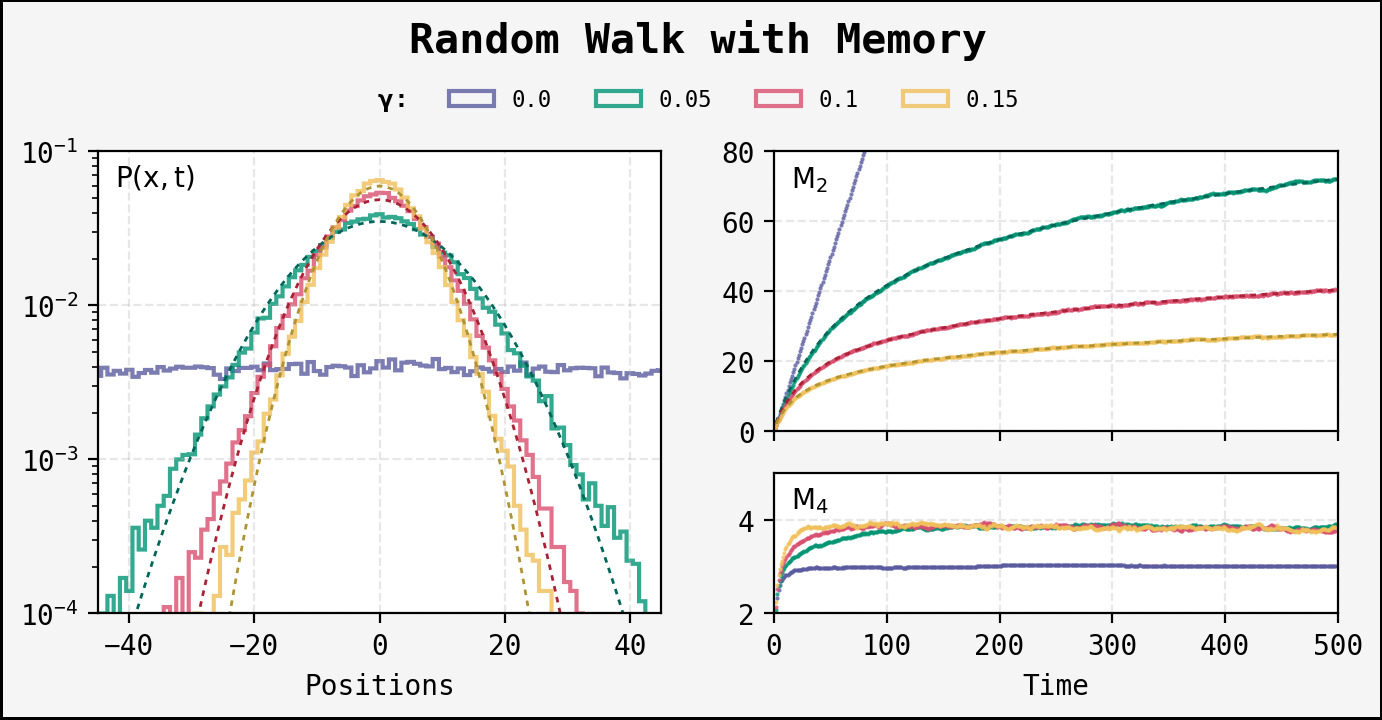

In [4]:
complements.distribution_probability_plotting('memory','position',memoryPositions['NorDistribution'],memoryPositions['Variance'],\
memoryPositions['Kurtosis'],memoryPositions['Cases'],memoryPositions['Information'],[45,memoryPositions['Information']['Time'][1]/2],\
[.1,80,2,5]);

<head><link rel="stylesheet" href="complements/style.css"></head>

We see that, although the walkers positions are constrained around the $\small 0$, the variance is not as slow as in the resetting case. Even though we could think the distribution coincides with a Gaussian, the kurtosis clearly indicates something different, and the approximation we proposed ends up backing this argument, as the tails grow larger.

<a class="return-to-contents" href="#contents">◄ Return to contents</a>

<h4 style="font-weight: bold; margin-bottom: 0; padding-top: 40px;" id="memory:vis">4.2. Visits</h3>
<hr style="border: solid 0.01px; height: 0px; width: 90%; margin-left: 0; margin-top: 10px;">

This is an extension of what we have seen about the visits distributions. However, given that we do not know the PDF for the final positions of a random walk with memory, we also have no information about the PDF for the visits. Unlike the relation between the PDF in the visits and in the final positions, there is no connection between the variance among cases.

In [5]:
memoryVisits = {};
memoryVisits['Information'],memoryVisits['Cases'],memoryVisits['Distribution'],memoryVisits['Variance'],\
memoryVisits['Skewness'],memoryVisits['Kurtosis'] = complements.reading_data('memory','visits');

In [6]:
# VALUES DISPLAY
display(memoryVisits['Information']);
print("\nCases:");
display(memoryVisits['Cases'].transpose());
print("\nDistribution:");
display(memoryVisits['Distribution'].iloc[memoryVisits['Information']['MaxDistance'][1]-50:\
                                             memoryVisits['Information']['MaxDistance'][1]+50].transpose());
print("\nVariance:");
display(memoryVisits['Variance'].iloc[0:100].transpose());

# NORMALIZING DISTRIBUTION
memoryVisits['NorDistribution'] = complements.normalization(memoryVisits['Distribution'],memoryVisits['Cases']);

,Cases,Realizations,Steps,MaxDistance,Time
1,4,100000,10000,400,1000



Cases:


,0,1,2,3
0,0.0,0.05,0.1,0.15



Distribution:


,-50,-49,-48,-47,-46,-45,-44,-43,-42,-41,-40,-39,-38,-37,-36,-35,-34,-33,-32,-31,-30,-29,-28,-27,-26,-25,-24,-23,-22,-21,-20,-19,-18,-17,-16,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0.00,3962656.0,4024435.0,4085522.0,4146936.0,4209523.0,4276524.0,4344673.0,4410196.0,4473423.0,4538212.0,4608343.0,4680652.0,4751591.0,4823557.0,4893436.0,4969218.0,5043244.0,5112982.0,5183644.0,5258728.0,5336124.0,5415961.0,5493485.0,5576968.0,5661398.0,5742755.0,5829112.0,5916592.0,5997260.0,6078744.0,6160874.0,6244182.0,6330904.0,6421660.0,6508705.0,6596616.0,6686759.0,6781206.0,6873489.0,6964094.0,7058965.0,7154467.0,7241813.0,7333500.0,7432622.0,7529652.0,7623233.0,7721577.0,7816988.0,7913634.0,8011418.0,7911223.0,7816129.0,7717185.0,7618221.0,7520922.0,7421132.0,7326330.0,7230629.0,7138274.0,7048662.0,6962148.0,6875437.0,6784326.0,6691788.0,6602221.0,6513056.0,6425824.0,6335858.0,6250568.0,6167532.0,6082120.0,5999956.0,5920958.0,5834065.0,5749937.0,5667445.0,5582134.0,5494443.0,5409018.0,5324847.0,5248377.0,5173558.0,5094348.0,5018074.0,4947583.0,4876882.0,4809449.0,4739703.0,4669505.0,4600010.0,4534112.0,4465510.0,4393632.0,4328573.0,4266243.0,4199157.0,4132273.0,4064379.0,4001622.0
0.05,16058.0,19700.0,24311.0,30210.0,37316.0,46021.0,57285.0,71352.0,88008.0,108173.0,132912.0,163084.0,199675.0,244419.0,299374.0,365302.0,444417.0,540468.0,655736.0,792742.0,959896.0,1160312.0,1396337.0,1676890.0,2007800.0,2397407.0,2852748.0,3384657.0,4011651.0,4742545.0,5585661.0,6548872.0,7653863.0,8913681.0,10335712.0,11927546.0,13702045.0,15672932.0,17825888.0,20160637.0,22658746.0,25286065.0,28008151.0,30769185.0,33524456.0,36163709.0,38614344.0,40747724.0,42435778.0,43558097.0,43977801.0,43376893.0,42088884.0,40240134.0,37974440.0,35411970.0,32647329.0,29810348.0,26975288.0,24185576.0,21501146.0,18974646.0,16623429.0,14463804.0,12498117.0,10731384.0,9164453.0,7782903.0,6574522.0,5532039.0,4632850.0,3861012.0,3205255.0,2651544.0,2188858.0,1800711.0,1475462.0,1205186.0,980843.0,796401.0,645820.0,524653.0,424478.0,341986.0,275273.0,220147.0,175713.0,139476.0,110965.0,88822.0,70531.0,56295.0,44595.0,35138.0,27632.0,21780.0,17511.0,13836.0,10728.0,8384.0
0.10,113.0,191.0,320.0,516.0,805.0,1127.0,1523.0,2142.0,3055.0,4260.0,5975.0,8213.0,11541.0,16240.0,22314.0,30382.0,41176.0,55606.0,74881.0,100067.0,133065.0,177612.0,235909.0,312777.0,414316.0,547353.0,718725.0,941637.0,1229968.0,1599103.0,2072486.0,2669344.0,3423487.0,4366612.0,5532861.0,6961123.0,8693838.0,10781804.0,13276305.0,16206590.0,19597503.0,23466435.0,27803576.0,32541752.0,37557642.0,42680204.0,47690192.0,52288064.0,56089053.0,58686564.0,59668594.0,58451747.0,55628452.0,51633046.0,46877033.0,41725276.0,36491755.0,31401038.0,26613255.0,22246335.0,18350773.0,14947304.0,12040605.0,9597605.0,7571554.0,5924104.0,4600562.0,3542784.0,2706642.0,2056919.0,1551195.0,1164735.0,871595.0,649627.0,482838.0,357277.0,263558.0,193884.0,141674.0,103367.0,75122.0,54254.0,39511.0,28615.0,20890.0,15196.0,11133.0,8138.0,5889.0,4188.0,2813.0,2047.0,1541.0,1126.0,829.0,591.0,427.0,301.0,202.0,137.0
0.15,9.0,10.0,10.0,15.0,30.0,43.0,76.0,123.0,174.0,303.0,461.0,669.0,1007.0,1541.0,2170.0,3161.0,4640.0,6765.0,9788.0,14413.0,21345.0,31601.0,46739.0,68112.0,97947.0,140348.0,199247.0,280495.0,395758.0,557438.0,782720.0,1095224.0,1521659.0,2096612.0,2868984.0,3898094.0,5250665.0,7003868.0,9260113.0,12122583.0,15684266.0,20016961.0,25191641.0,31229033.0,38026983.0,45409486.0,53015104.0,60316346.0,66575440.0,70933965.0,72581856.0,70583137.0,65854876.0,59287670.0,51736059.0,43946940.0,36428080.0,29521536.0,23455138.0,18280062.0,13983473.0,10518889.0,7783682.0,5679691.0,4091816.0,2911065.0,2045192.0,1422818.0,981047.0,673660.0,459606.0,311132.0,209308.0,140394.0,93606.0,62179.0,41223.0,27154.0,18013.0,11883.0,7766.0,5087.0,3249.0,2038.0,1288.0,779.0,486.0,327.0,198.0,114.0,69.0,38.0,


Variance:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99
0.00,0.0,0.499995,0.998227,1.496360,1.993721,2.495372,2.998924,3.499102,3.999141,4.497937,4.996572,5.495508,5.992966,6.489179,6.989199,7.490576,7.992062,8.491389,8.991175,9.490901,9.990685,10.491134,10.991813,11.492076,11.992744,12.491810,12.990723,13.489752,13.989270,14.489213,14.989512,15.488782,15.987668,16.485681,16.983791,17.481516,17.978018,18.475822,18.973482,19.471849,19.970785,20.469637,20.967657,21.464586,21.960520,22.457695,22.955965,23.453167,23.949429,24.447214,24.944590,25.442249,25.939524,26.437349,26.935015,27.432180,27.928614,28.426289,28.923990,29.421806,29.919514,30.417559,30.915619,31.412363,31.909439,32.406750,32.905746,33.403801,33.900276,34.397659,34.895950,35.395222,35.894764,36.393627,36.892189,37.391334,37.889671,38.387550,38.885811,39.384502,39.882851,40.381615,40.880527,41.378525,41.876019,42.372963,42.870888,43.369701,43.868614,44.368404,44.868881,45.370388,45.871941,46.373444,46.876213,47.378876,47.882271,48.385647,48.888607,49.391724
0.05,0.0,0.475218,0.940614,1.397578,1.847616,2.293558,2.733260,3.163803,3.587346,4.002861,4.412417,4.814814,5.208733,5.596164,5.981248,6.362201,6.739707,7.109974,7.472683,7.830552,8.184397,8.533517,8.877710,9.215183,9.547396,9.873656,10.196902,10.515670,10.830068,11.138439,11.443245,11.744221,12.038972,12.329560,12.615580,12.897012,13.172528,13.445571,13.715379,13.982714,14.246779,14.508860,14.768278,15.024320,15.275954,15.525993,15.773439,16.017263,16.257273,16.495220,16.730732,16.964998,17.196348,17.423634,17.647308,17.867809,18.085310,18.300999,18.514624,18.727339,18.938582,19.148277,19.353977,19.558193,19.760302,19.961182,20.159920,20.357027,20.551346,20.743366,20.933628,21.123434,21.310154,21.492989,21.674999,21.855404,22.034496,22.213095,22.390411,22.565708,22.739080,22.910696,23.081678,23.250996,23.419353,23.585791,23.750984,23.913752,24.076754,24.237843,24.397944,24.556500,24.712934,24.867443,25.021309,25.172901,25.323574,25.472990,25.621477,25.768429
0.10,0.0,0.449989,0.883140,1.302316,1.708568,2.103860,2.487710,2.857644,3.217063,3.562609,3.899375,4.224744,4.542621,4.851254,5.152612,5.446862,5.733202,6.009217,6.279459,6.542150,6.799858,7.050416,7.294769,7.531979,7.763868,7.990273,8.211679,8.429059,8.640612,8.847540,9.049738,9.248468,9.442309,9.632702,9.820075,10.002512,10.181614,10.357409,10.530419,10.701063,10.868705,11.035031,11.195600,11.351777,11.504339,11.654523,11.801215,11.945756,12.087979,12.229625,12.368162,12.505087,12.641377,12.774888,12.905578,13.034966,13.163588,13.289186,13.412240,13.532989,13.652515,13.770864,13.887424,14.002903,14.116281,14.228310,14.339611,14.449953,14.557270,14.663887,14.769475,14.874262,14.977363,15.078620,15.178842,15.278976,15.377552,15.475376,15.572073,15.667327,15.760608,15.852441,15.943579,16.033558,16.121912,16.208885,16.295361,16.380301,16.465752,16.550117,16.633947,16.718086,16.801149,16.884430,16.966761,17.047356,17.126303,17.204601,17.282547,17.359402
0.15,0.0,0.425653,0.828748,1.212872,1.579034,1.928682,2.262796,2.580903,2.886300,3.176466,3.455081,3.721369,3.977932,4.225523,4.463450,4.695518,4.920496,5.135504,5.343631,5.543119,5.736399,5.922094,6.102072,6.274961,6.444539,6.610275,6.771369,6.929116,7.081378,7.231214,7.376953,7.518160,7.655979,7.791095,7.922416,8.050633,8.174294,8.298243,8.420314,8.540777,8.658409,8.774725,8.888760,8.998637,9.105051,9.208481,9.309505,9.409197,9.507150,9.604068,9.698018,9.790642,9.882848,9.973074,10.061956,10.148188,10.233897,10.316664,10.398404,10.480074,10.561341,10.641320,10.720369,10.797265,10.872932,10.948049,11.021892,11.094960,11.166042,11.236837,11.306757,11.375657,11.443301,11.509637,11.574030,11.638229,11.701797,11.764834,11.827352,11.889287,11.949999,12.011852,12.073831,12.134605,12.19

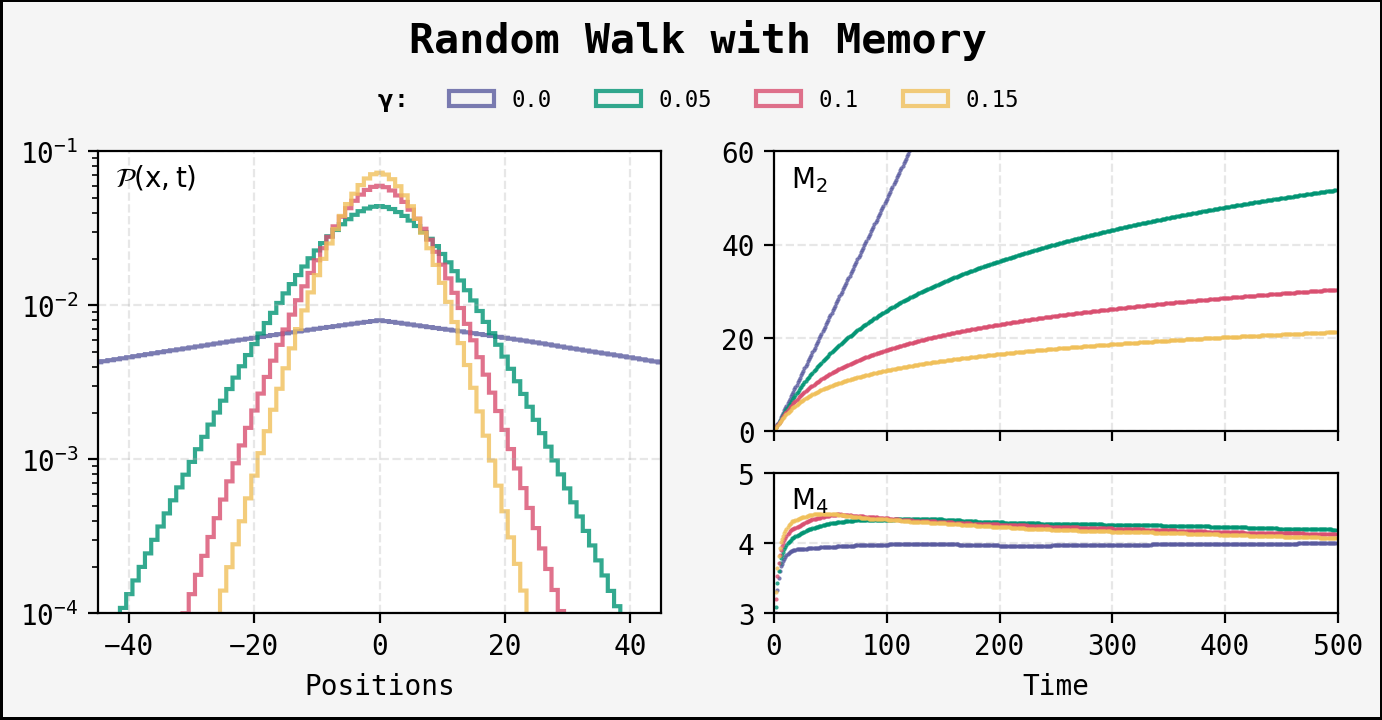

In [8]:
complements.distribution_probability_plotting('memory','visits',memoryVisits['NorDistribution'],memoryVisits['Variance'],\
memoryVisits['Kurtosis'],memoryVisits['Cases'],memoryVisits['Information'],[45,memoryVisits['Information']['Time'][1]/2],\
[.1,60,3,5]);

<head><link rel="stylesheet" href="complements/style.css"></head>

<a class="return-to-contents" href="#contents">◄ Return to contents</a>